In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv")

In [3]:
df.shape

(1040200, 35)

In [4]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,1.0,986.821602,0,0.000692,1.0,1.109330,0.795094,1,986.821602,1
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,1.0,1754.958804,0,0.000495,1.0,1.203289,4.415985,4,7019.835216,1


In [5]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month

monthly_df = (
    df.groupby(['store_name', 'year', 'month'])['sales_amount_realistic']
    .sum()
    .reset_index()
)

monthly_df['date'] = pd.to_datetime(
    monthly_df[['year', 'month']].assign(day=1)
)

monthly_df = monthly_df.sort_values(['store_name', 'date'])

In [6]:
monthly_df['store_id'] = monthly_df['store_name'].astype('category').cat.codes

In [7]:
monthly_df['month_sin'] = np.sin(2 * np.pi * monthly_df['month'] / 12)
monthly_df['month_cos'] = np.cos(2 * np.pi * monthly_df['month'] / 12)

In [8]:
for lag in [1,3,6,12]:
    monthly_df[f'lag_{lag}'] = (
        monthly_df.groupby('store_id')['sales_amount_realistic']
        .shift(lag)
    )

In [9]:
monthly_df['rolling_mean_3'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(3).mean().reset_index(0, drop=True)
)

monthly_df['rolling_mean_6'] = (
    monthly_df.groupby('store_id')['sales_amount_realistic']
    .rolling(6).mean().reset_index(0, drop=True)
)

In [10]:
monthly_df = monthly_df.dropna().reset_index(drop=True)

In [11]:
feature_cols = [
    'store_id',
    'month_sin',
    'month_cos',
    'lag_1',
    'lag_3',
    'lag_6',
    'lag_12',
    'rolling_mean_3',
    'rolling_mean_6'
]

In [12]:
def create_sequences_multi(X, y, input_window=12, output_window=12):
    X_seq, y_seq = [], []

    for i in range(len(X) - input_window - output_window + 1):
        X_seq.append(X[i:i+input_window])
        y_seq.append(y[i+input_window:i+input_window+output_window])

    return np.array(X_seq), np.array(y_seq)

In [13]:
X_all = []
y_all = []
store_ids_per_sample = []

for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[monthly_df['store_id'] == store_id]
    
    X = store_data[feature_cols].values
    y = store_data['sales_amount_realistic'].values
    
    X_seq, y_seq = create_sequences_multi(X, y)
    
    X_all.append(X_seq)
    y_all.append(y_seq)
    
    store_ids_per_sample.extend([store_id] * len(X_seq))

X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)
store_ids_per_sample = np.array(store_ids_per_sample)

In [14]:
split = int(len(X_all) * 0.8)

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

store_ids_train = store_ids_per_sample[:split]
store_ids_test = store_ids_per_sample[split:]

In [15]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d = X_test.reshape(-1, X_test.shape[2])

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [16]:
model = Sequential([
    LSTM(256, return_sequences=True, input_shape=(12, len(feature_cols))),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(12)   # predict 12 months
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

d:\anaconda\envs\Apple\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 256)        │       272,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,548 (2.00 MB)

 Trainable params: 525,548 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.7022 - mae: 0.6145 - val_loss: 0.2563 - val_mae: 0.3638
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2849 - mae: 0.3811 - val_loss: 0.1992 - val_mae: 0.3190
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.2597 - mae: 0.3677 - val_loss: 0.1874 - val_mae: 0.3181
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.2276 - mae: 0.3464 - val_loss: 0.1784 - val_mae: 0.3088
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2192 - mae: 0.3419 - val_loss: 0.1833 - val_mae: 0.3215
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2217 - mae: 0.3453 - val_loss: 0.1764 - val_mae: 0.3099
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.2089 - mae: 0.3340 - val_loss: 0.1650 - val_mae: 0.3059
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.2023 - mae: 0.3286 - val_loss: 0.1557 - val_mae: 0.2898
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - l

In [18]:
y_pred_scaled = model.predict(X_test_scaled)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_scaled)

mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))
r2 = r2_score(y_true.flatten(), y_pred.flatten())

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
MAE: 229929.23866525962
RMSE: 295922.9084776897
R2: 0.904373396318071


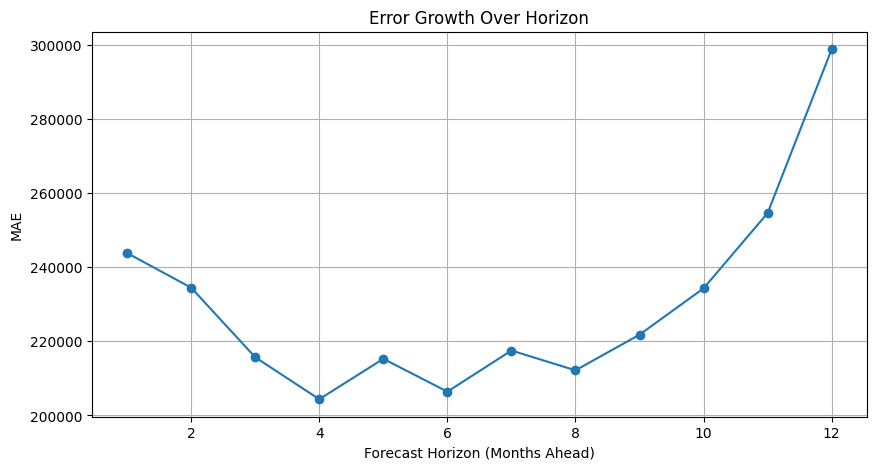

In [19]:
horizon_mae = []

for i in range(12):
    mae_i = np.mean(np.abs(y_true[:, i] - y_pred[:, i]))
    horizon_mae.append(mae_i)

plt.figure(figsize=(10,5))
plt.plot(range(1,13), horizon_mae, marker='o')
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("MAE")
plt.title("Error Growth Over Horizon")
plt.grid(True)
plt.show()

In [20]:
store_errors = []

for store_id in np.unique(store_ids_test):
    
    mask = store_ids_test == store_id
    
    true_store = y_true[mask]
    pred_store = y_pred[mask]
    
    mae_store = np.mean(np.abs(true_store - pred_store))
    
    store_errors.append((store_id, mae_store))

store_error_df = pd.DataFrame(
    store_errors,
    columns=["store_id", "MAE"]
).sort_values("MAE", ascending=False)

store_error_df.head()

,store_id,MAE
0,55,315881.111938
10,65,288929.770137
1,56,277547.031951
13,68,276531.637736
7,62,268801.083081


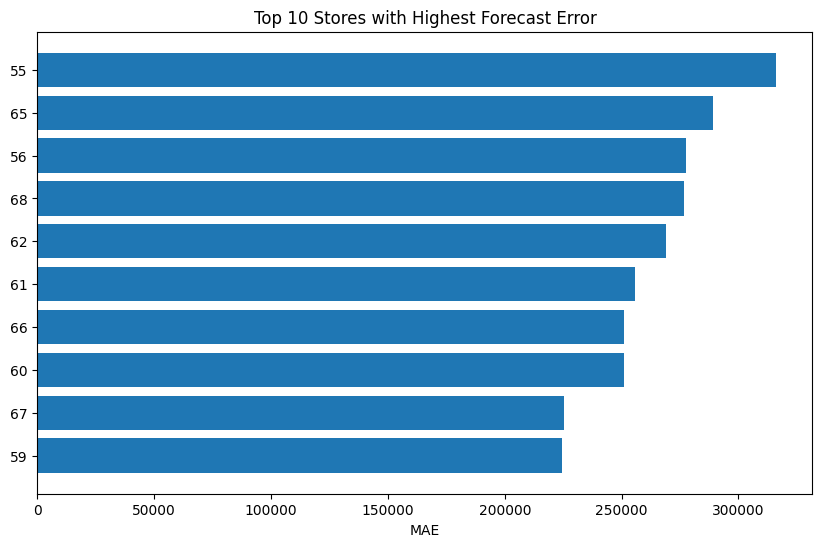

In [21]:
top_worst = store_error_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_worst['store_id'].astype(str), top_worst['MAE'])
plt.xlabel("MAE")
plt.title("Top 10 Stores with Highest Forecast Error")
plt.gca().invert_yaxis()
plt.show()

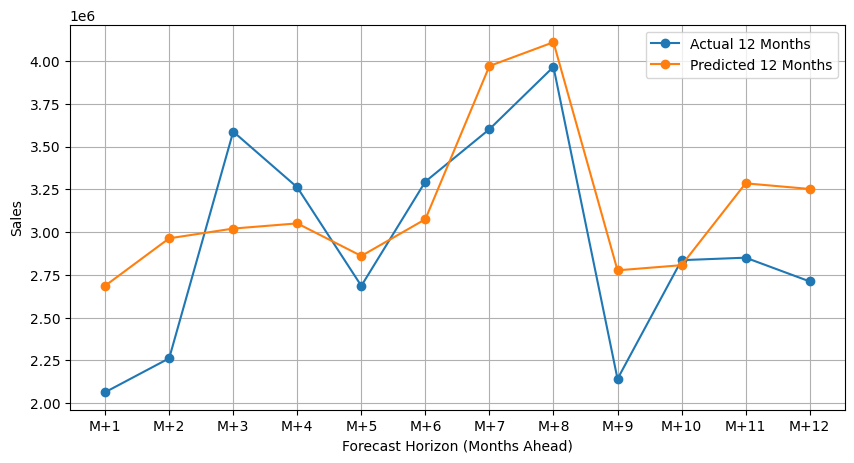

In [22]:
months = np.arange(1, 13)
months = [f"M+{i}" for i in range(1,13)]
plt.figure(figsize=(10,5))

plt.plot(months, y_true[0], marker='o', label="Actual 12 Months")
plt.plot(months, y_pred[0], marker='o', label="Predicted 12 Months")

plt.xticks(months)
plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
y_true.shape   # (samples, 12)
y_pred.shape   # (samples, 12)

(332, 12)

In [24]:
import numpy as np
import pandas as pd

horizon_mae = []
horizon_rmse = []
horizon_r2 = []

for i in range(12):
    
    true_i = y_true[:, i]
    pred_i = y_pred[:, i]
    
    mae_i = np.mean(np.abs(true_i - pred_i))
    rmse_i = np.sqrt(np.mean((true_i - pred_i)**2))
    r2_i = 1 - (np.sum((true_i - pred_i)**2) / np.sum((true_i - np.mean(true_i))**2))
    
    horizon_mae.append(mae_i)
    horizon_rmse.append(rmse_i)
    horizon_r2.append(r2_i)

horizon_df = pd.DataFrame({
    "Horizon": range(1,13),
    "MAE": horizon_mae,
    "RMSE": horizon_rmse,
    "R2": horizon_r2
})

horizon_df

,Horizon,MAE,RMSE,R2
0,1,243809.877679,307229.430792,0.896867
1,2,234456.706298,297352.482960,0.903641
2,3,215689.279918,281765.149980,0.913815
3,4,204364.659798,273120.048898,0.918493
4,5,215266.758299,282509.217251,0.911883
5,6,206402.325408,261414.397752,0.924930
6,7,217506.904060,269519.927881,0.920088
7,8,212161.843888,271780.618540,0.918485
8,9,221778.755309,284878.471822,0.909844
9,10,234291.922970,293768.569696,0.905320


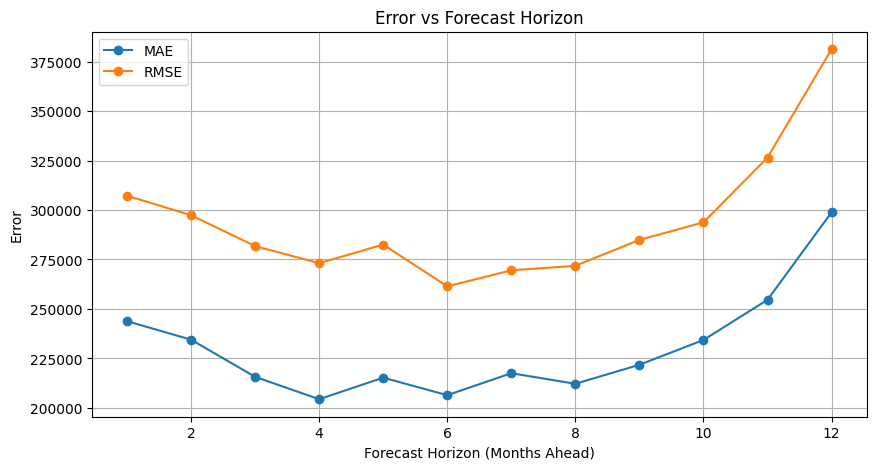

In [25]:
plt.figure(figsize=(10,5))

plt.plot(range(1,13), horizon_mae, marker='o', label='MAE')
plt.plot(range(1,13), horizon_rmse, marker='o', label='RMSE')

plt.xlabel("Forecast Horizon (Months Ahead)")
plt.ylabel("Error")
plt.title("Error vs Forecast Horizon")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
def forecast_2025_for_store(store_id):

    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date').copy()

    last_12 = store_data.tail(12)

    X_input = last_12[feature_cols].values
    X_input_scaled = scaler.transform(X_input)
    X_input_scaled = X_input_scaled.reshape(1, 12, len(feature_cols))

    y_pred_scaled = model.predict(X_input_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)[0]

    last_date = last_12['date'].iloc[-1]

    future_dates = [
        last_date + pd.DateOffset(months=i+1)
        for i in range(12)
    ]

    forecast_df = pd.DataFrame({
        "store_id": store_id,
        "date": future_dates,
        "forecast_2025": y_pred
    })

    return forecast_df

In [27]:
forecast_all_2025 = []

for store_id in monthly_df['store_id'].unique():
    forecast_store = forecast_2025_for_store(store_id)
    forecast_all_2025.append(forecast_store)

forecast_all_2025 = pd.concat(forecast_all_2025).reset_index(drop=True)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━

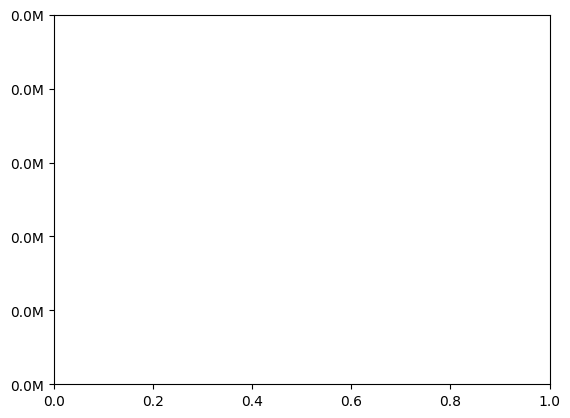

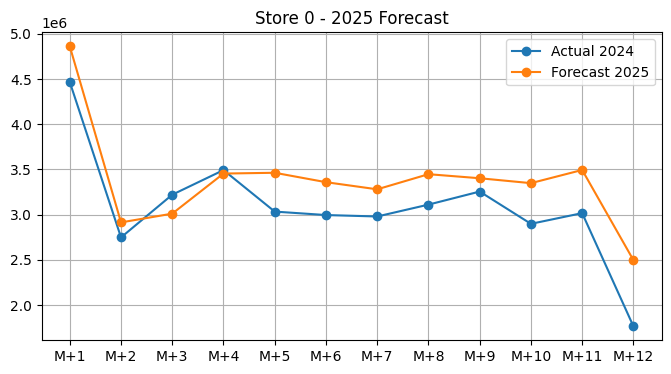

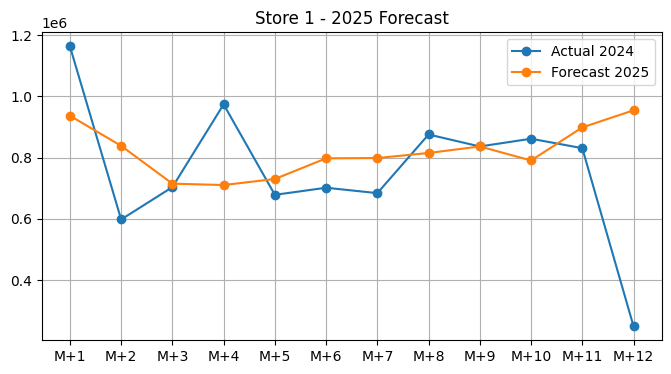

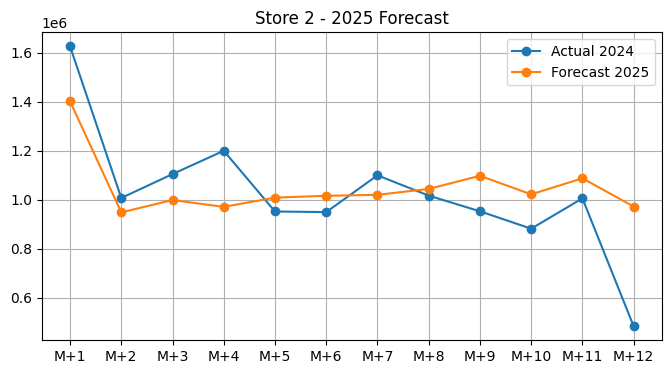

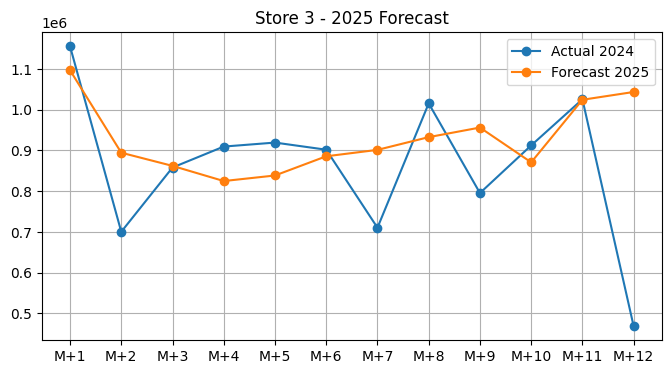

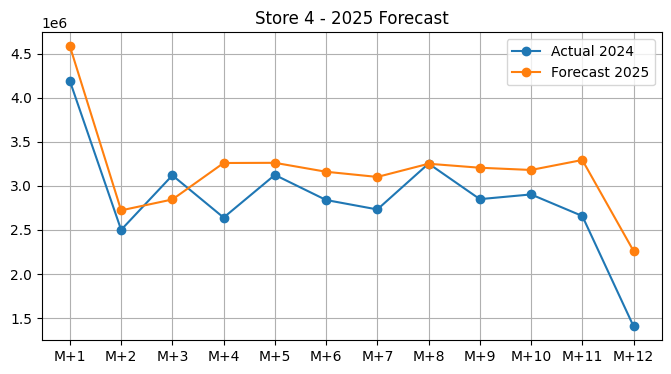

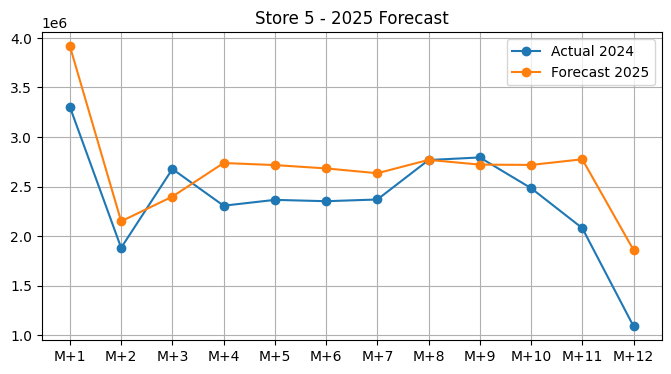

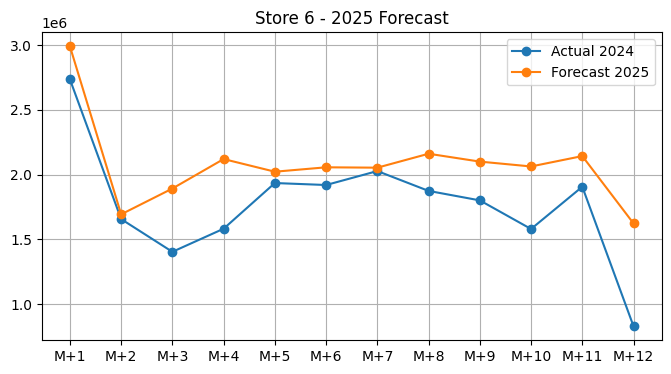

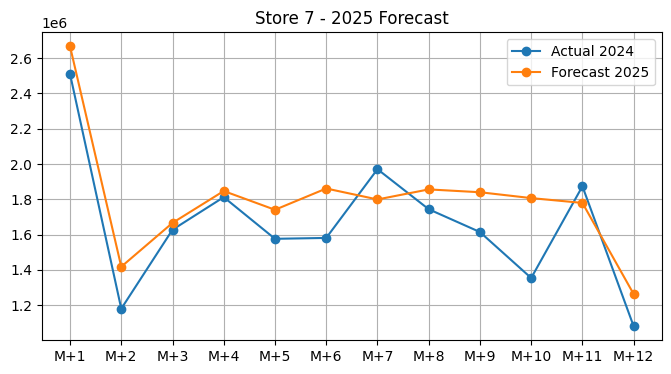

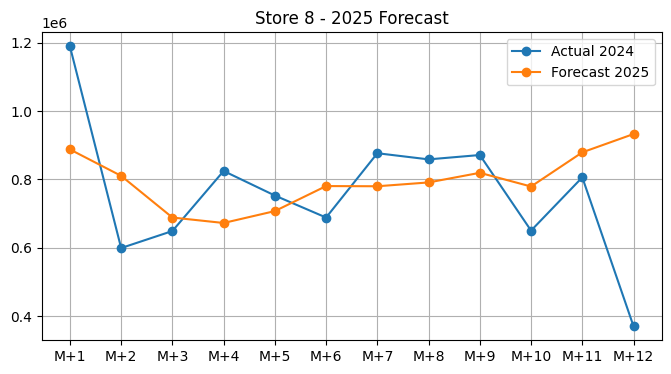

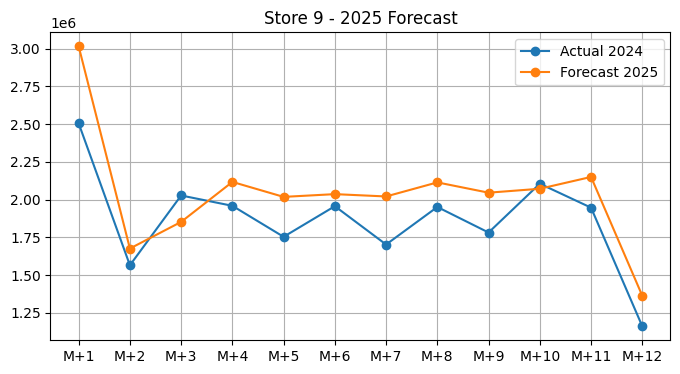

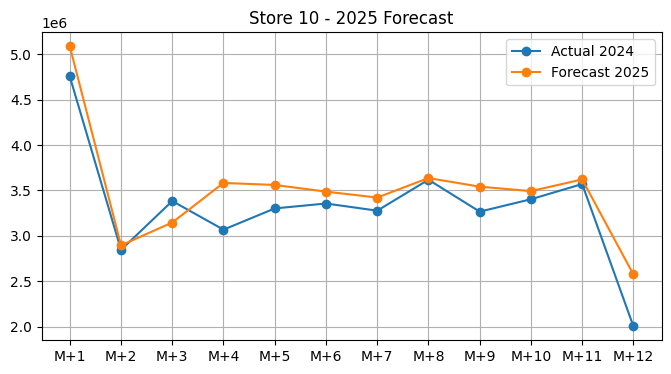

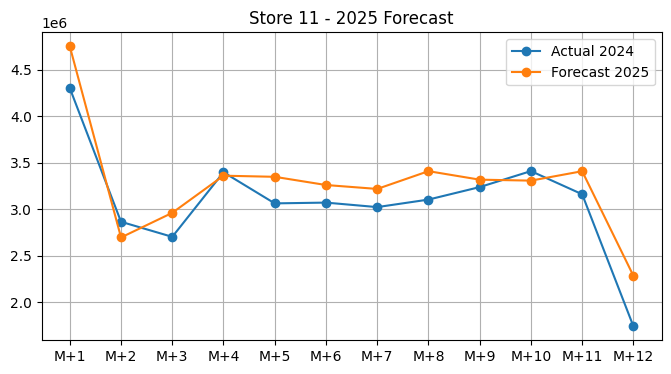

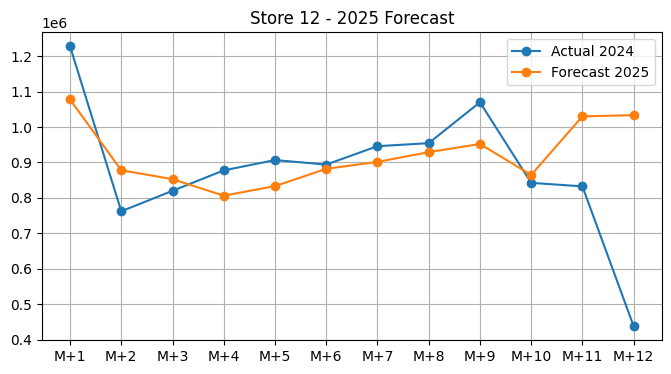

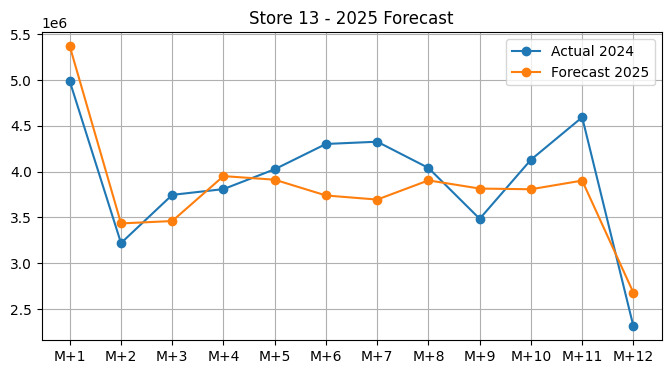

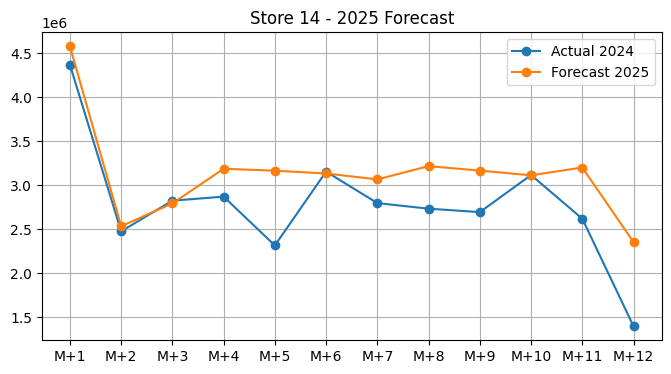

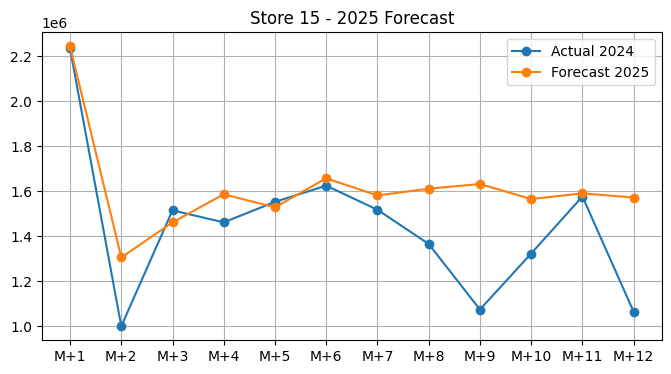

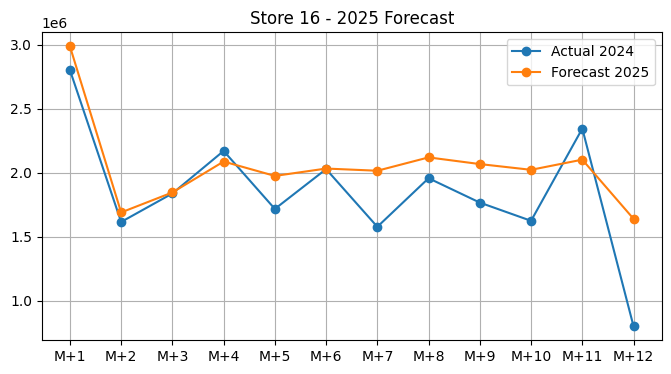

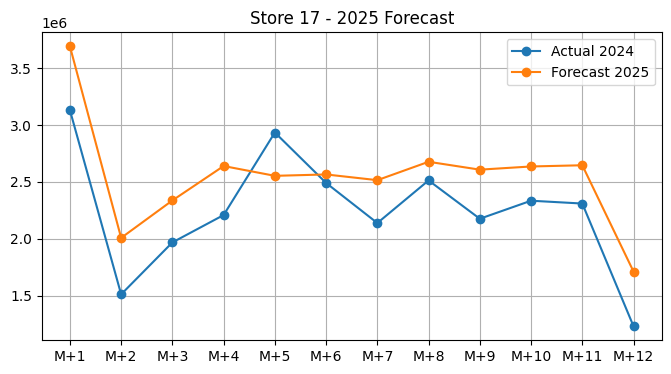

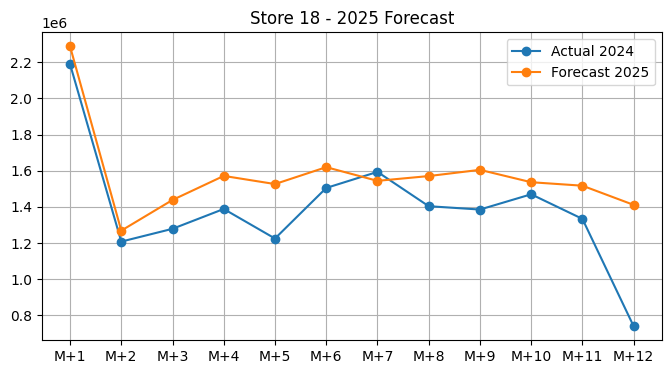

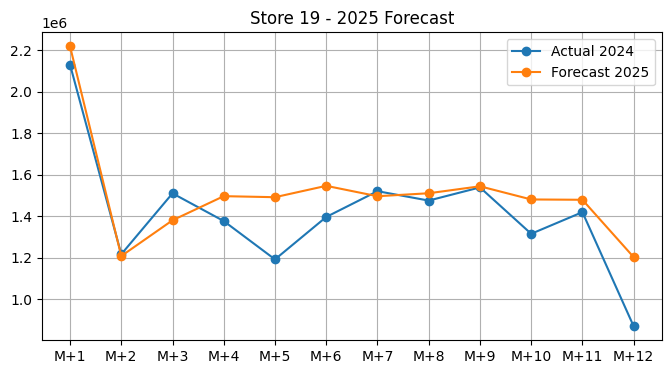

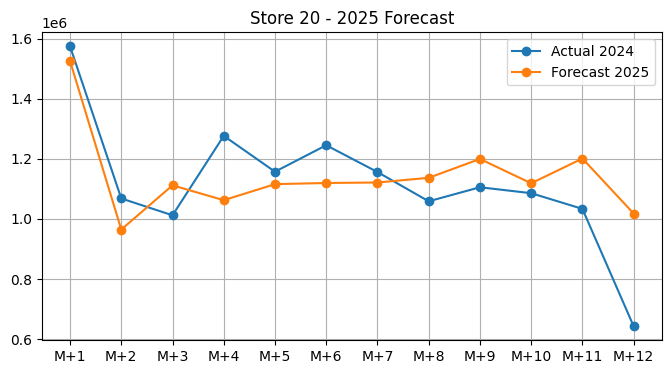

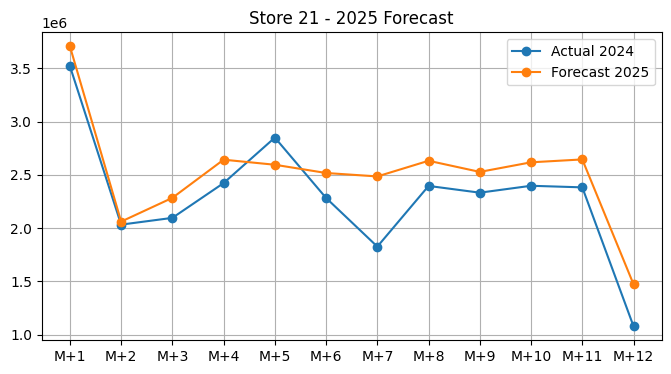

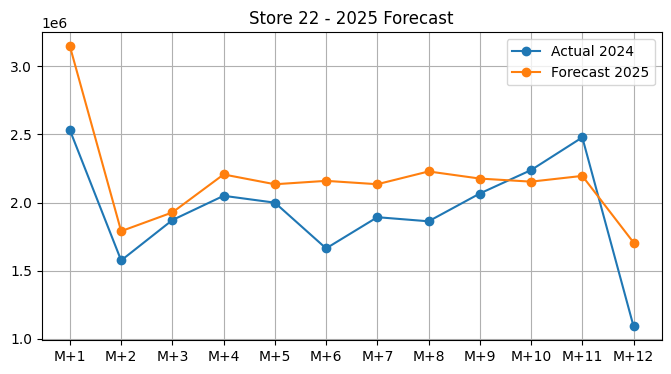

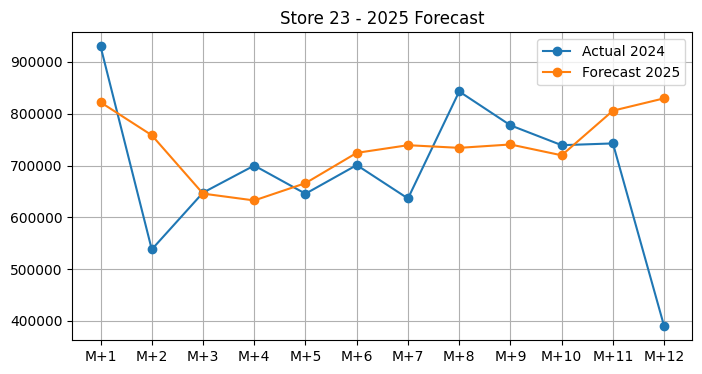

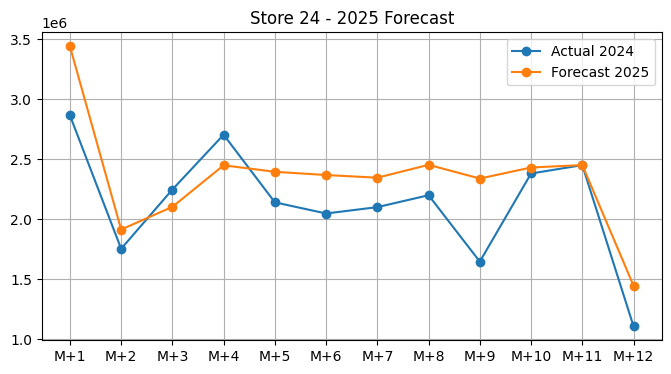

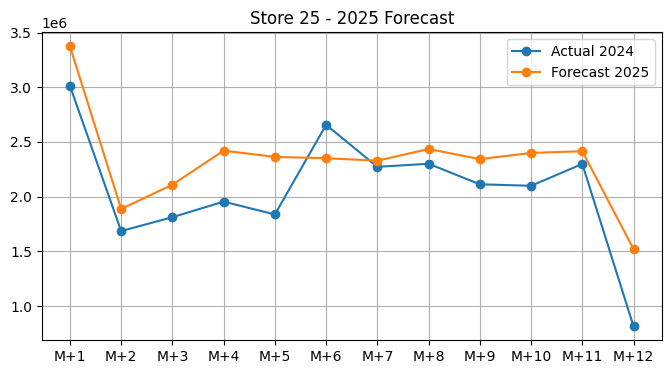

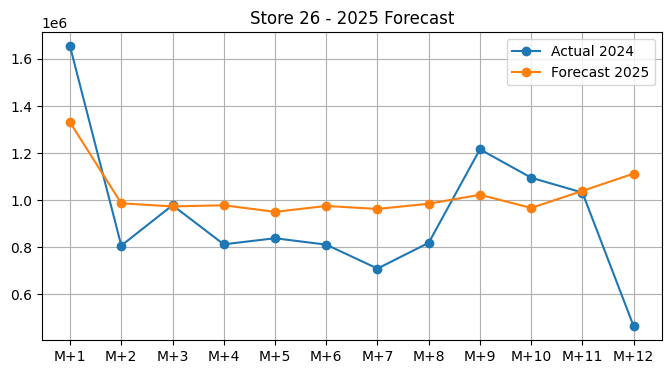

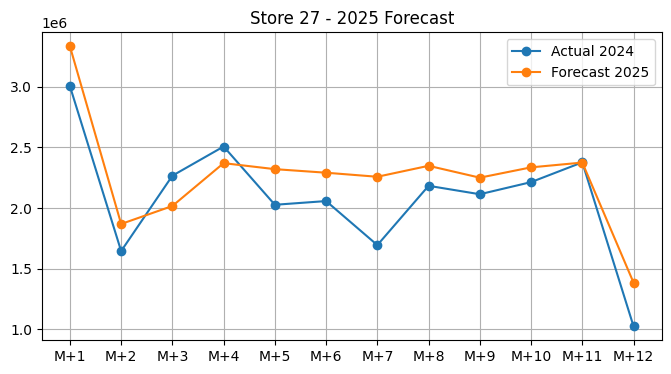

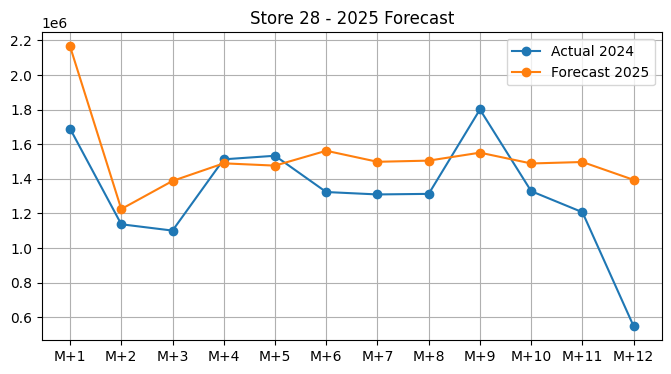

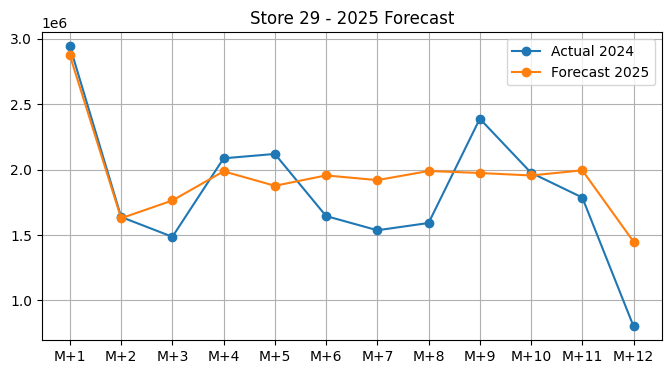

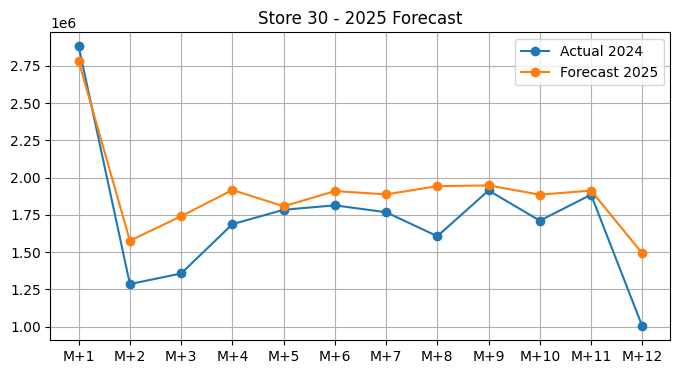

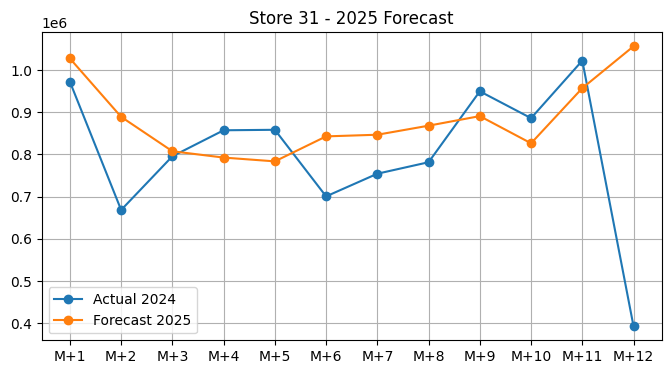

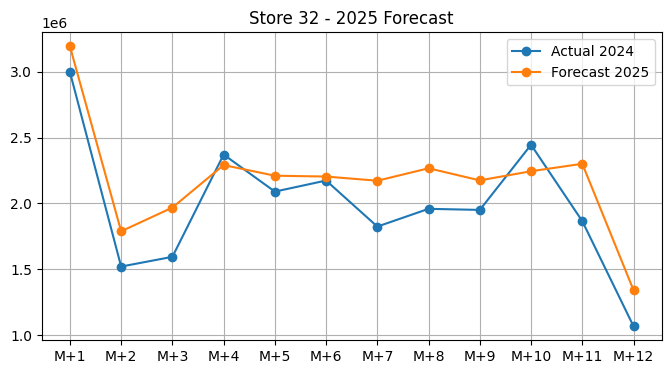

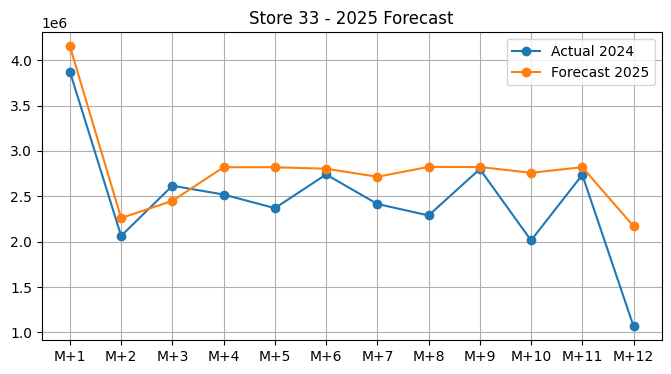

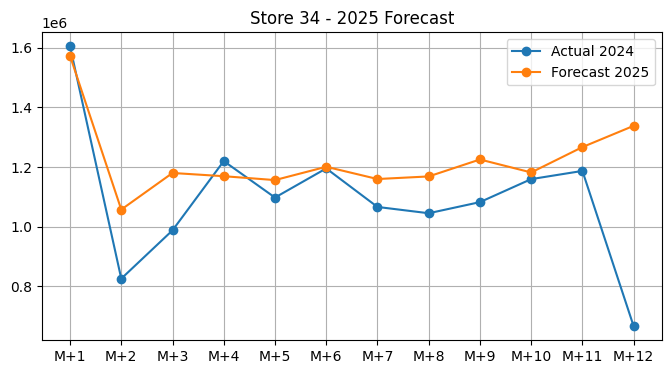

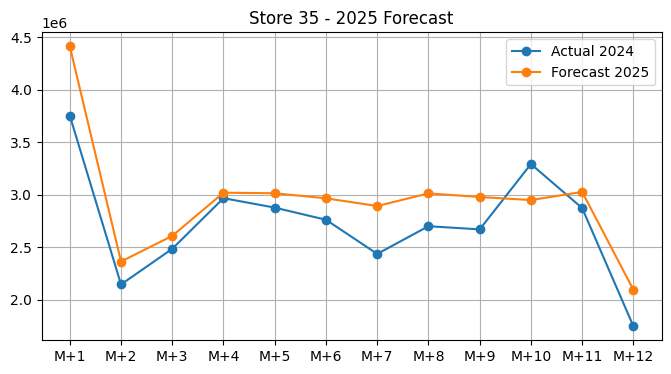

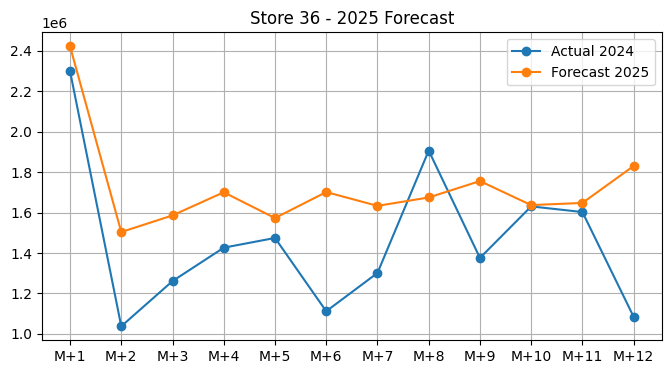

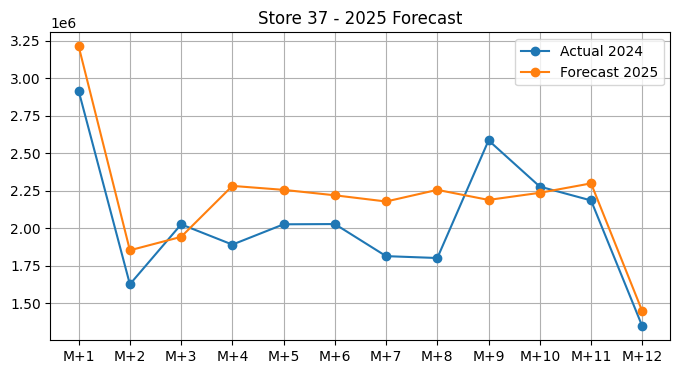

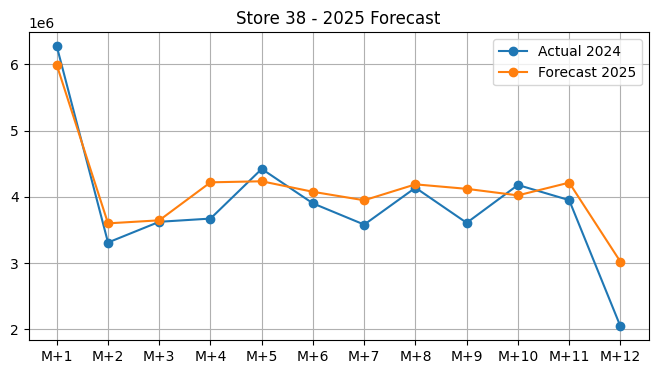

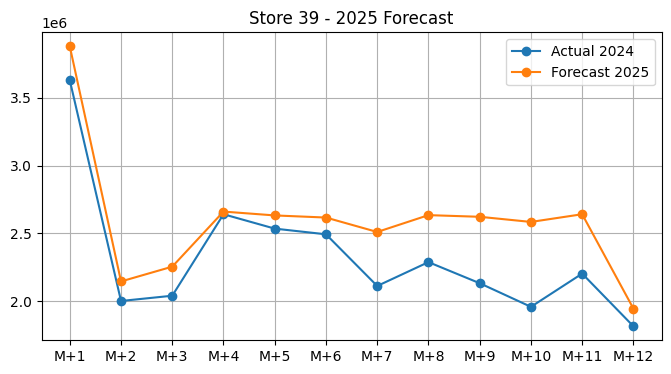

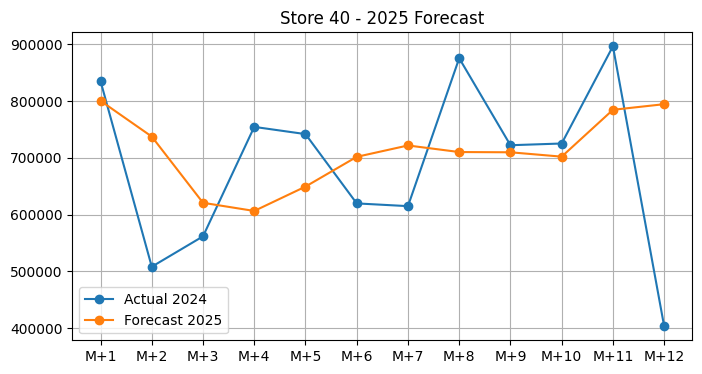

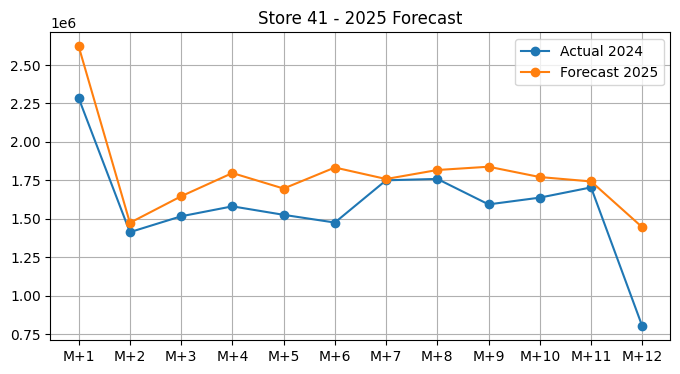

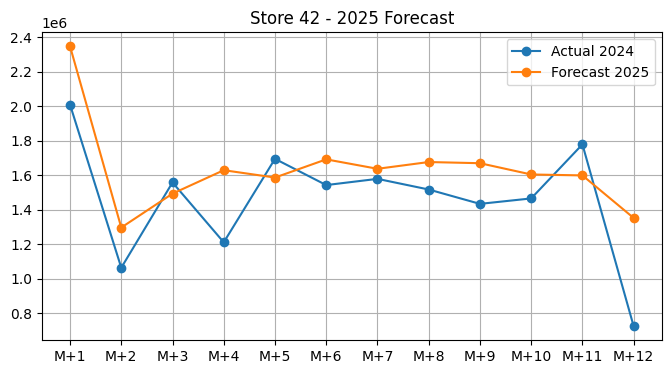

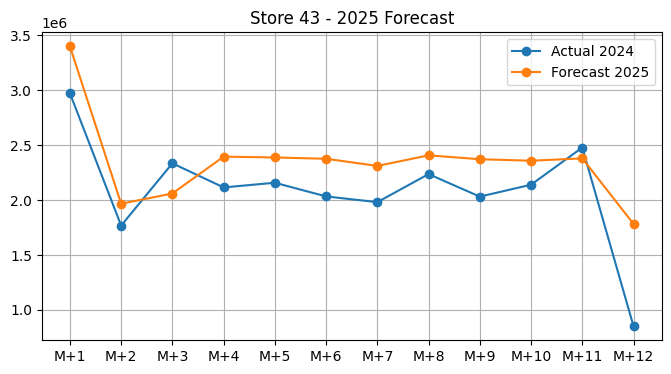

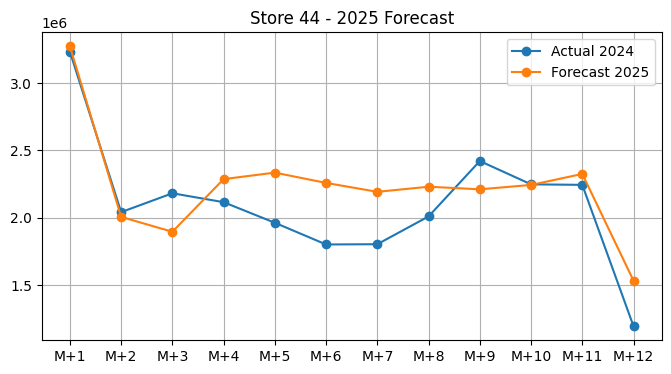

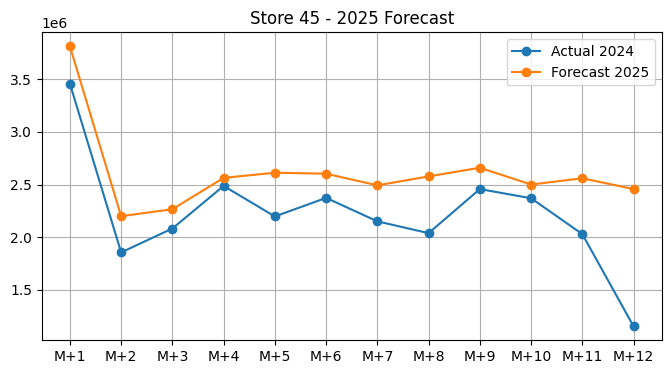

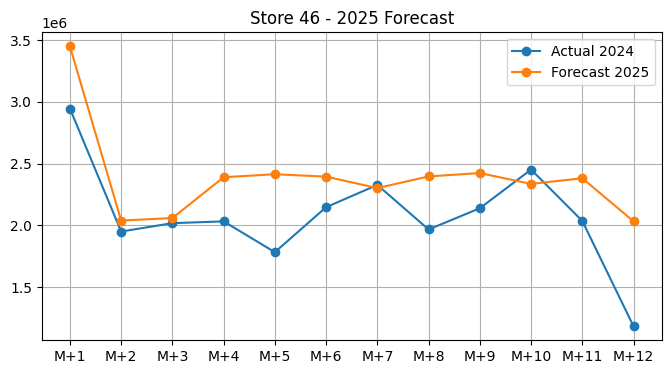

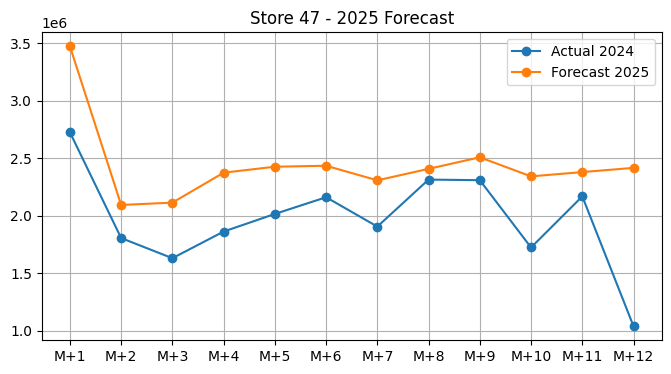

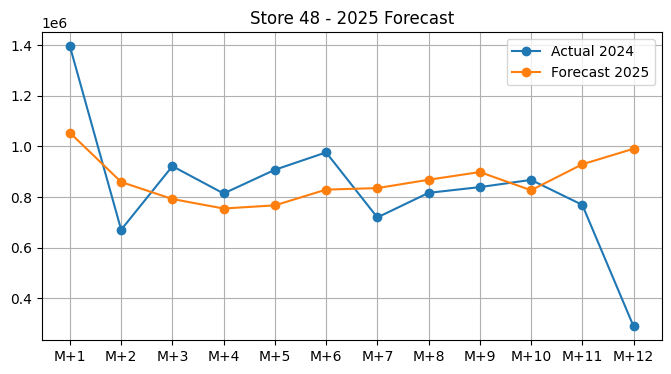

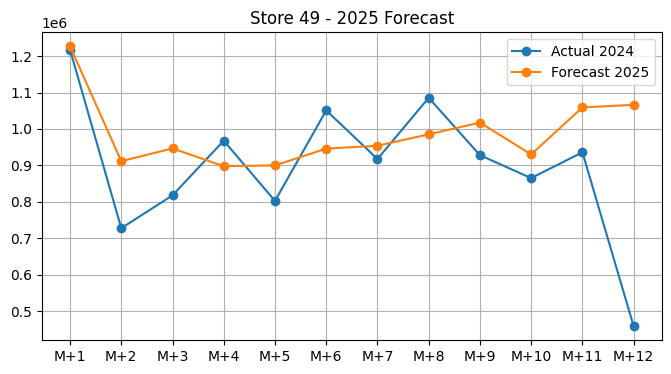

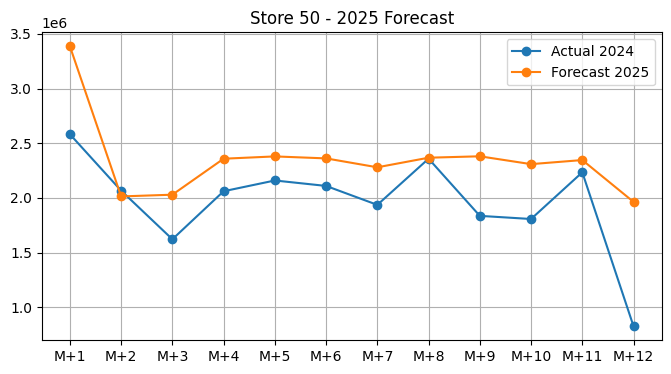

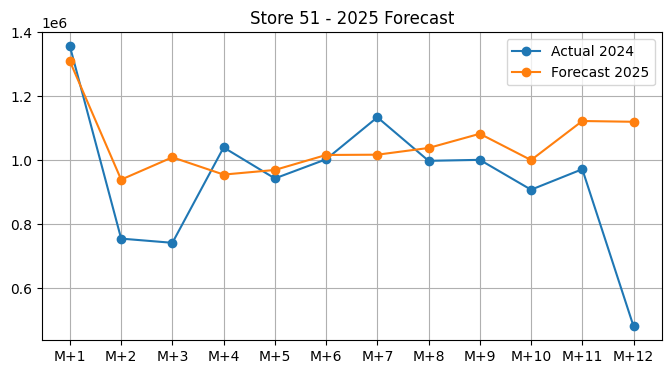

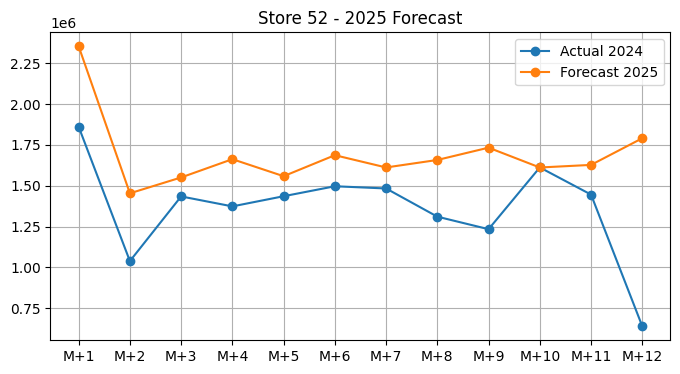

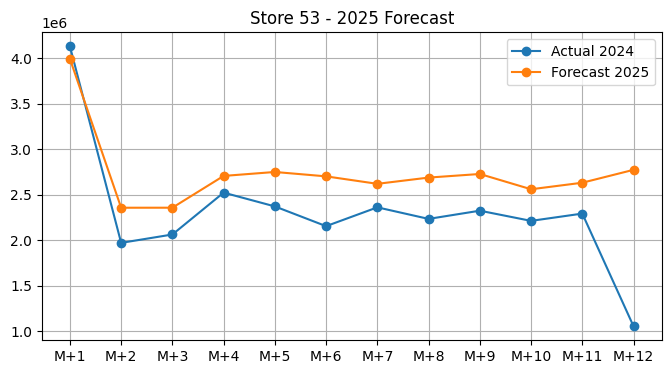

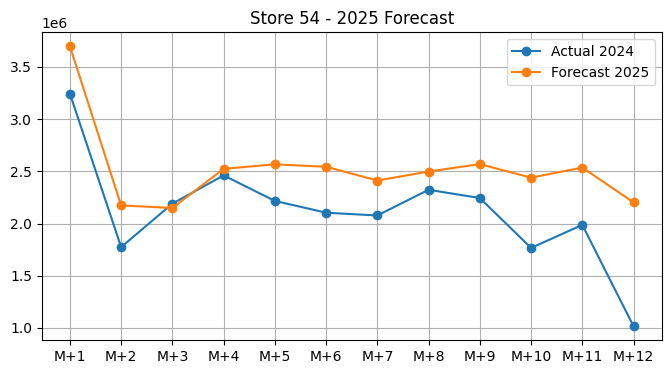

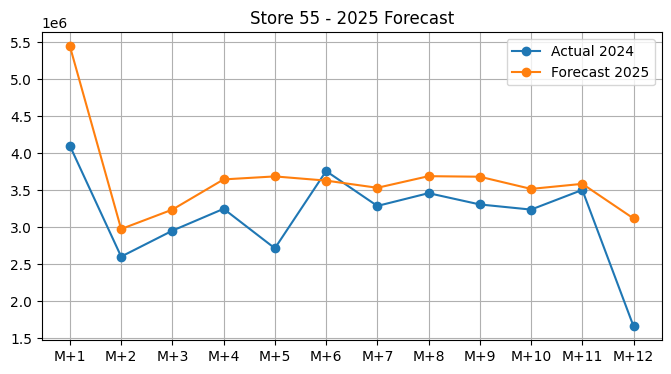

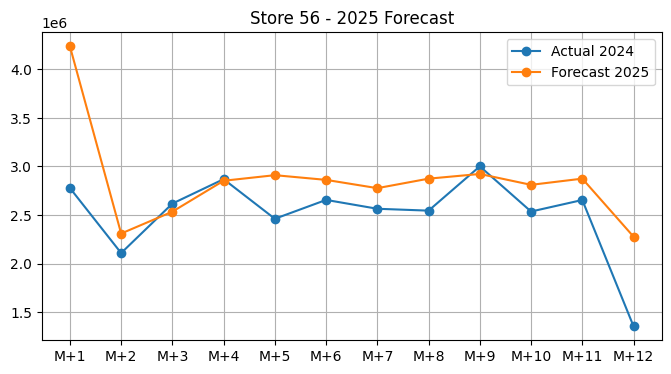

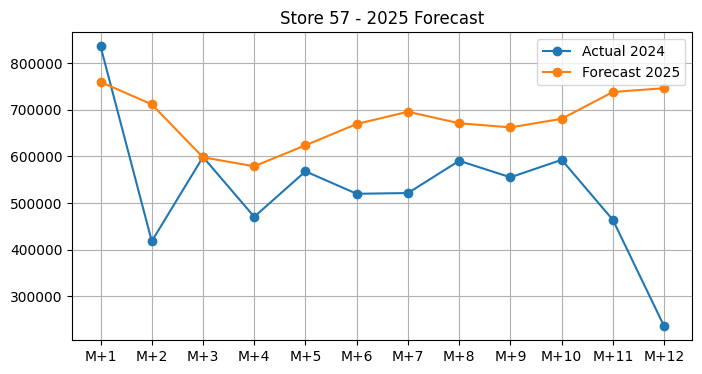

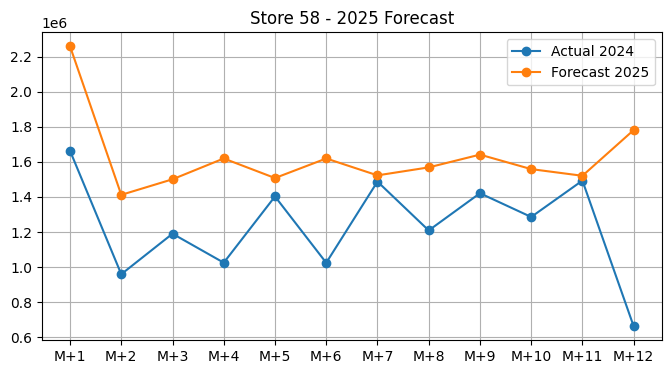

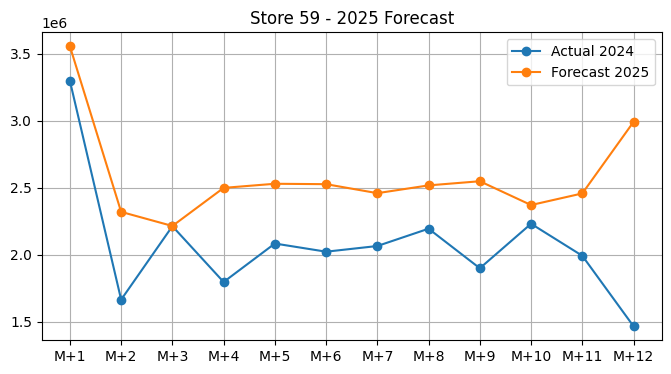

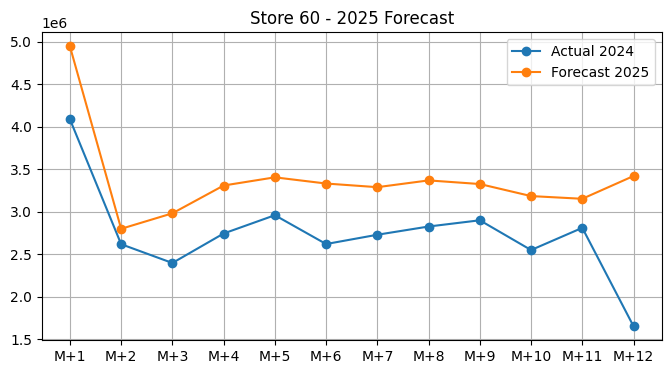

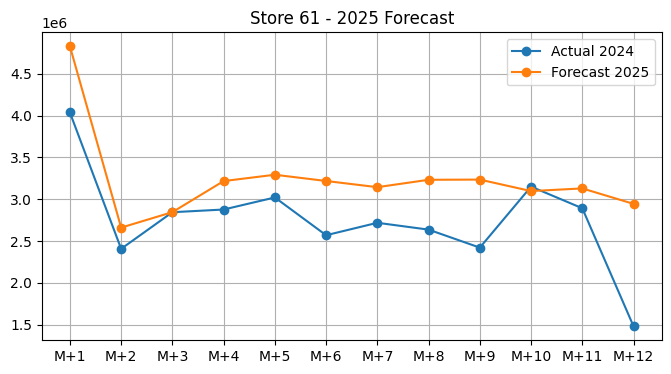

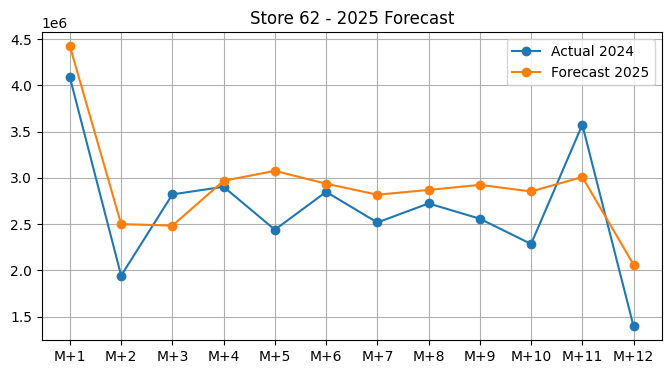

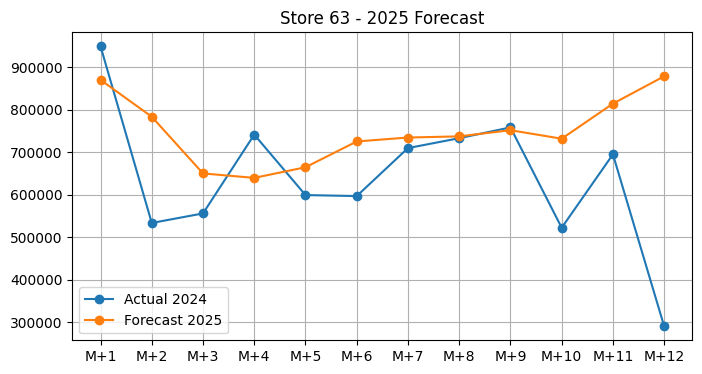

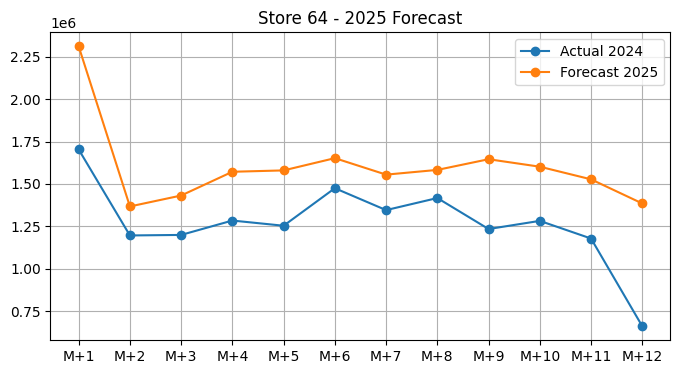

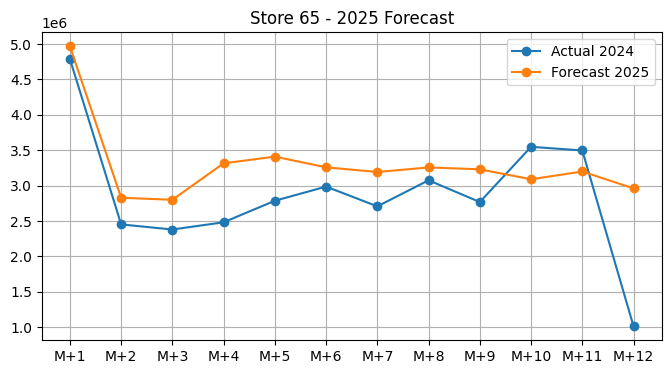

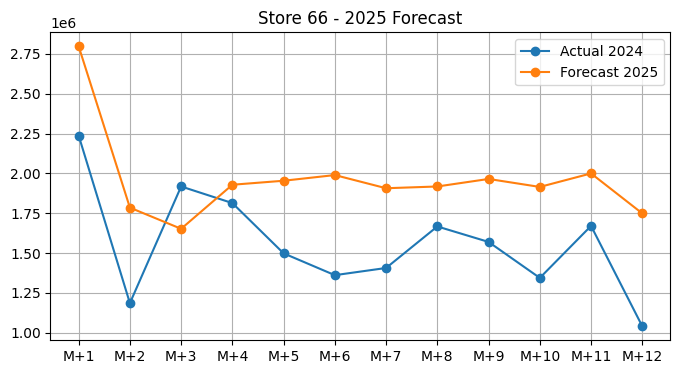

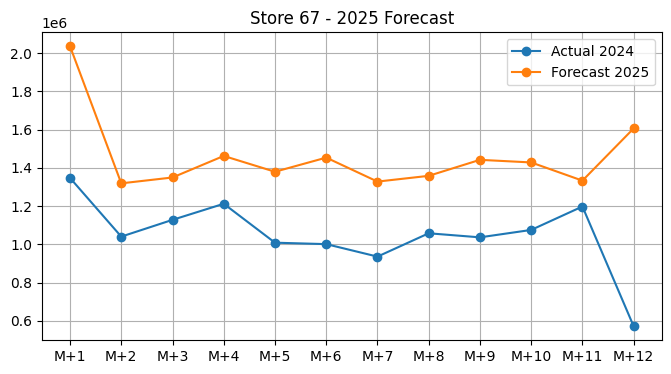

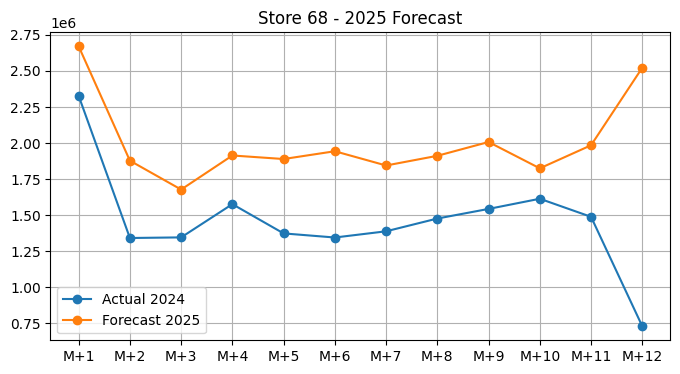

In [28]:
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M')
)
for store_id in monthly_df['store_id'].unique():
    
    store_data = monthly_df[
        monthly_df['store_id'] == store_id
    ].sort_values('date')

    actual_2024 = store_data['sales_amount_realistic'].tail(12).values

    forecast_store = forecast_all_2025[
        forecast_all_2025['store_id'] == store_id
    ]

    forecast_2025 = forecast_store['forecast_2025'].values

    months = [f"M+{i}" for i in range(1,13)]

    plt.figure(figsize=(8,4))

    plt.plot(months, actual_2024, marker='o', label="Actual 2024")
    plt.plot(months, forecast_2025, marker='o', label="Forecast 2025")

    plt.title(f"Store {store_id} - 2025 Forecast")
    plt.legend()
    plt.grid(True)
    plt.show()

In [29]:
df.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


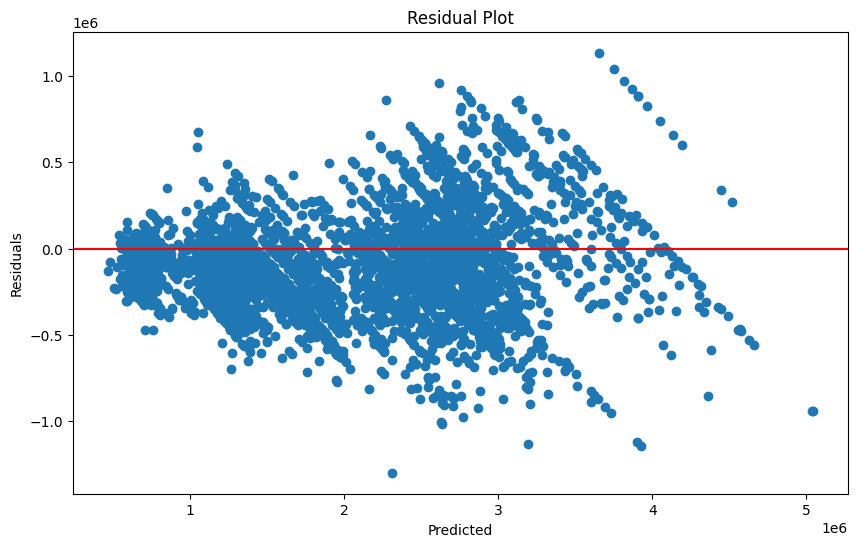

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red')

plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()